In [134]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd

In [135]:
#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy/InRelease  Connection failed [IP: 91.189.91.81 80]
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-updates/InRelease  Connection failed [IP: 91.189.91.82 80]
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-backports/InRelease  Connection failed [IP: 185.125.190.83 80]
W: Some index files failed to download. They have been ignored, or old ones used instead.


# 1. 코로나 발생 주여국거 동향 꺽은선 그래프 그리기

In [136]:
filename = '/content/drive/MyDrive/Colab Notebooks/data/주요발생국가주간동향(4월2째주).csv'

In [137]:
data = pd.read_csv(filename,index_col = '국가')

In [138]:
chartdata = data['4월06일']
chartdata

,4월06일
국가,
미국,335524
스페인,130709
이탈리아,128948
독일,100024
프랑스,70478
중국,81708
영국,47806
이란,58226
스위스,21104


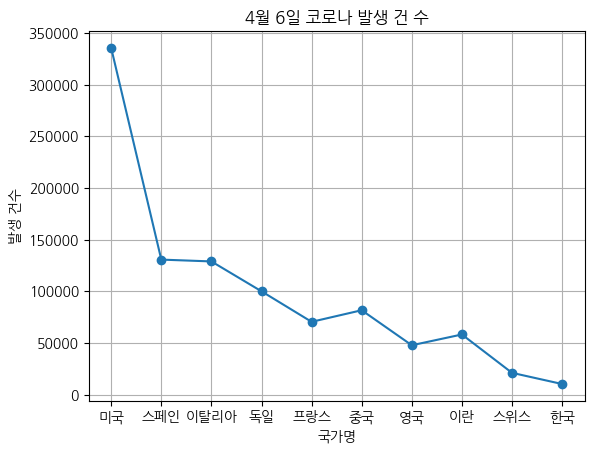

In [139]:
plt.plot(chartdata,marker='o')
plt.xlabel('국가명')
plt.ylabel('발생 건수')
plt.title('4월 6일 코로나 발생 건 수')
plt.grid(True)

In [140]:
country = ['스페인','프랑스','독일','중국','이란','영국']
day = ['4월06일','4월07일','4월08일','4월09일','4월10일']

In [141]:
chartdata2 = data.loc[country,day]
chartdata2 = chartdata2.T

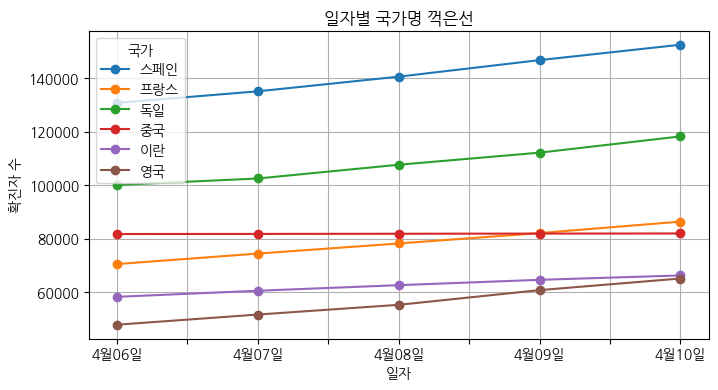

In [142]:
chartdata2.plot(figsize=(8,4),legend=True,marker='o')
plt.title('일자별 국가명 꺽은선')
plt.xlabel('일자')
plt.ylabel('확진자 수')
plt.grid(True)

# 2. 이중축 꺽은선 그레프

In [143]:
tip = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/tips.csv')
tip

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


In [144]:
tip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [145]:
len(tip)

244

In [146]:
xrange = range(len(tip))
data_bill = tip.loc[:,'total_bill']
data_tip = tip.loc[:,'tip']

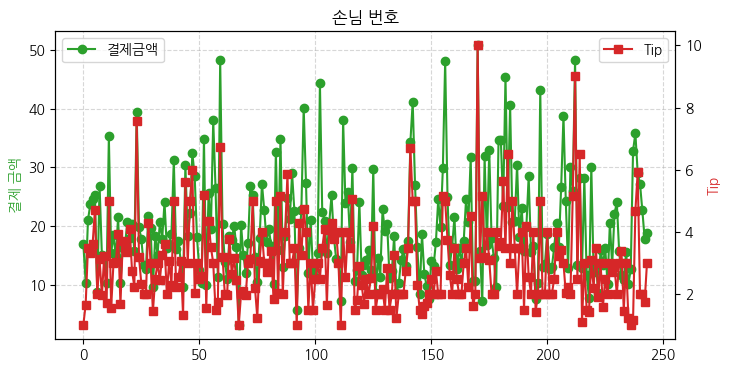

In [147]:
fig , ax1 = plt.subplots(figsize=(8,4))
ax1.set_title('결제 금액과 Tip(이중 축)')

# 결제 금액(왼쪽 y축)
color = "tab:green"
ax1.set_title('손님 번호')
ax1.set_ylabel('결제 금액',color=color)
ax1.plot(xrange,data_bill,color=color,marker='o',label='결제금액')
plt.grid(True,alpha=0.5,linestyle='--')

# tip(오른쪽 y축)
# ax1.twinx() : x축을 공유하면서 y축을 분리하는 부분
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Tip',color=color)
ax2.plot(xrange,data_tip,color=color,marker='s',label='Tip')

# 범례
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

# 3. 꺽은선 그래프 연습해보기

In [148]:
die = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/연령별_실업율.csv',index_col='연도',encoding='cp949')
die

,20대,30대,40대,50대,60세이상
연도,,,,,
2001년,7.4,3.2,3.0,2.8,1.2
2002년,6.6,2.9,2.0,2.0,1.1
2003년,7.7,2.8,2.2,2.2,1.0
2004년,7.9,3.2,2.3,2.8,1.2
2005년,7.7,3.4,2.4,2.4,1.3
2006년,7.7,3.0,2.8,2.4,1.6
2007년,7.1,3.2,2.1,2.2,1.3
2008년,7.0,3.1,2.2,2.1,1.2
2009년,7.9,3.6,2.5,2.5,1.6


In [149]:
die = die[:5]
die = die.T
die

연도,2001년,2002년,2003년,2004년,2005년
20대,7.4,6.6,7.7,7.9,7.7
30대,3.2,2.9,2.8,3.2,3.4
40대,3.0,2.0,2.2,2.3,2.4
50대,2.8,2.0,2.2,2.8,2.4
60세이상,1.2,1.1,1.0,1.2,1.3


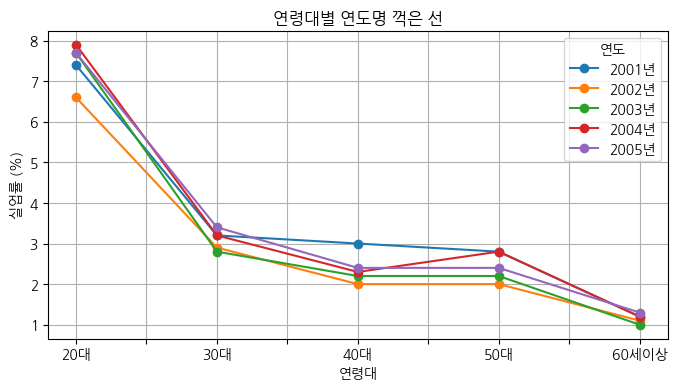

In [150]:
die.plot(figsize=(8,4),legend=True,marker='o')
plt.title('연령대별 연도명 꺽은 선')
plt.xlabel('연령대')
plt.ylabel('실업률 (%)')
plt.grid(True)

# 4. 산점도 그래프 그리기

In [151]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/mpg.csv',encoding='utf-8')
data.head()

# manufacturer : 제조사
# model:모델
# displ : 엔진크기
# year : 연식
# hwy :  gallon 당 고속도로 주행 마일 수
# cyl : 실린더의 수
# trans : 변속기
# drv : 구동방식 사륜(4), 전류(f), 후륜(r)

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


In [152]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    object 
 1   model         234 non-null    object 
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    object 
 6   drv           234 non-null    object 
 7   cty           234 non-null    int64  
 8   hwy           234 non-null    int64  
 9   fl            234 non-null    object 
 10  class         234 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 20.2+ KB


In [153]:
data.isnull().sum()

,0
manufacturer,0
model,0
displ,0
year,0
cyl,0
trans,0
drv,0
cty,0
hwy,0
fl,0


In [154]:
# 두개의 변수간의 관계를 그래프로 나타내기
#X = data['displ']
#y = data['hwy']

xdata = data.loc[:,['displ']]
ydata = data.loc[:,['hwy']]

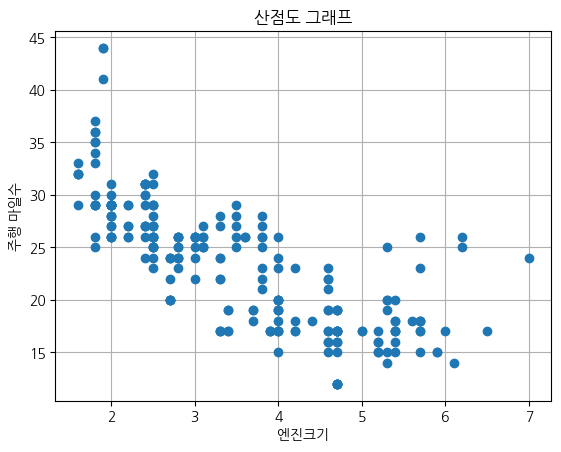

In [155]:
plt.figure()
plt.plot(xdata,ydata,marker='o',linestyle='None')
plt.xlabel('엔진크기')
plt.ylabel('주행 마일수')
plt.title('산점도 그래프')
plt.grid()
plt.show()

In [156]:
# 구동방식에 따라서 색상구분

colorlist = ['r','g','b']
label_dict={'f':'전류구동','4':'사륜구동','r':'후륜구동'}

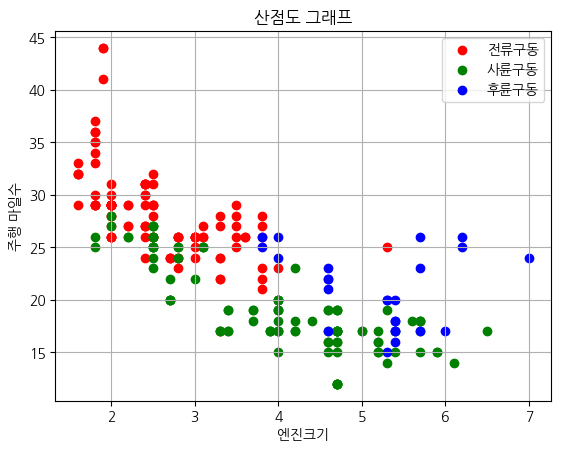

In [157]:
plt.figure()
idx = 0
labels = data['drv'].unique()

for i in labels:
  xdata = data.loc[data['drv']==i,'displ']
  ydata = data.loc[data['drv']==i,'hwy']
  plt.scatter(xdata,ydata,color=colorlist[idx],label = label_dict[i])
  idx = idx+1

plt.legend()
plt.xlabel('엔진크기')
plt.ylabel('주행 마일수')
plt.title('산점도 그래프')
plt.grid()
plt.show()

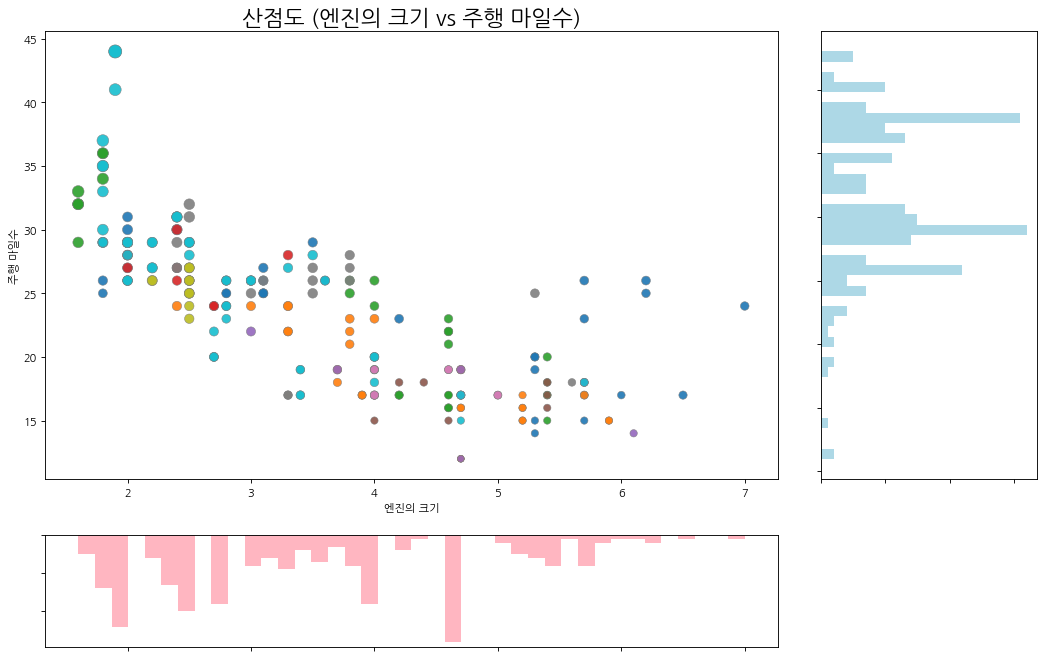

In [158]:
fig = plt.figure(figsize=(16,10),dpi=80)
grid = plt.GridSpec(4,4,hspace=0.5,wspace=0.2)

ax_main = fig.add_subplot(grid[:-1,:-1])
ax_right = fig.add_subplot(grid[:-1,-1],xticklabels=[],yticklabels=[])
ax_bottom = fig.add_subplot(grid[-1,0:-1],xticklabels=[],yticklabels=[])

# 도시연비(cty)에 비례해서 정보를 시각화
# 제조사별로 색상 구분

ax_main.scatter('displ','hwy',
                 s = data.cty*4,
                 c = data.manufacturer.astype('category').cat.codes,
                 alpha=0.9, data=data, cmap='tab10',
                 edgecolors='gray',linewidths=0.5
                 )

ax_bottom.hist(data.displ,40,histtype='stepfilled',
               orientation='vertical',color='lightpink')
ax_bottom.invert_yaxis()

ax_right.hist(data.hwy,40,histtype='stepfilled',
               orientation='horizontal',color='lightblue')
ax_right.invert_yaxis()

ax_main.set(title='산점도 (엔진의 크기 vs 주행 마일수)',
            xlabel='엔진의 크기', ylabel = '주행 마일수')
ax_main.title.set_fontsize(20)

# 4. 다이아몬드 데이터셋과 산점도
- 약 54.000개의 다이아몬드에 대한 속성을 기록
- 전체 53,940개의 데이터와 10개의 변수로 구성

<특성>  
price : 다이아몬드 가격  
carat : 무게  
cut : 컷의 품질(Fair, good, very good, preminum ideal)  
color : 색상(j-가장 나쁨 , D-가장 좋음)  
clarity : 선명도  
depth table price  
x:길이  y: 폭  

In [159]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/diamonds.csv')
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [160]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [161]:
# 데이터의 일부분만 샘플링

f = 0.05
data = data.sample(frac=f)
data.info(())

<class 'pandas.core.frame.DataFrame'>
Index: 2697 entries, 21677 to 50859
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    2697 non-null   float64
 1   cut      2697 non-null   object 
 2   color    2697 non-null   object 
 3   clarity  2697 non-null   object 
 4   depth    2697 non-null   float64
 5   table    2697 non-null   float64
 6   price    2697 non-null   int64  
 7   x        2697 non-null   float64
 8   y        2697 non-null   float64
 9   z        2697 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 231.8+ KB


In [162]:
data.describe()

,carat,depth,table,price,x,y,z
count,2697.000000,2697.000000,2697.000000,2697.000000,2697.000000,2697.000000,2697.000000
mean,0.785669,61.720912,57.542788,3812.130145,5.701795,5.703608,3.518102
std,0.466310,1.465491,2.260705,3866.692878,1.115924,1.106899,0.692188
min,0.200000,44.000000,52.000000,357.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,929.000000,4.700000,4.700000,2.900000
50%,0.700000,61.800000,57.000000,2377.000000,5.670000,5.690000,3.510000
75%,1.040000,62.500000,59.000000,5156.000000,6.530000,6.510000,4.030000
max,3.000000,72.900000,73.000000,18806.000000,9.320000,9.190000,5.500000


In [163]:
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
21677,2.01,Very Good,I,SI2,61.4,63.0,9781,8.19,7.96,4.96
27833,0.31,Very Good,H,VVS1,61.9,57.0,651,4.33,4.36,2.69
11084,0.81,Ideal,F,VVS2,62.2,53.9,4926,5.97,6.01,3.72
38428,0.35,Ideal,D,VS1,61.4,56.0,1026,4.55,4.58,2.80
21513,2.00,Fair,I,SI2,65.0,57.0,9610,8.01,7.96,5.19


In [164]:
xdata = data['price']
ydata = data['carat']
table = data['table']

In [165]:
table.max()

73.0

In [166]:
table.min()

52.0

In [167]:
# cut은 품질에 따른 색깔 지정
colorlist = ['r','g','b','y','m']
cutlist = data['cut'].unique()

In [168]:
# 품질에 따른 색상정보를 딕셔너리로 저장
n = len(cutlist)
cut_dict = {cutlist[i]:colorlist[i] for i in range(n)}

In [169]:
#cut 품질에 따른 색상을 반환해주는 함수

def recode_cut(cut):
  return cut_dict[cut]

In [170]:
# 문자열 데이터를 범주형 데이터로 변환

data['newcut'] = data['cut'].apply(recode_cut)
newcut = data['newcut']

In [171]:
def recode_table(table):
  if table>=60:
    return 100

  elif table>=58:
    return 30

  elif table>=58:
    return 30

  elif table>=54:
    return 5

  else:
    return 1

In [172]:
data['newtable'] = data['table'].apply(recode_table)
newtable = data['newtable']

Text(0, 0.5, 'carat')

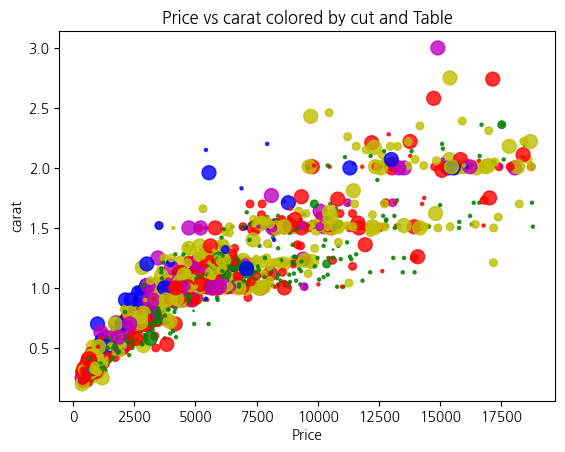

In [177]:
scatter__plot = plt.figure()
ax1 = scatter__plot.add_subplot(1,1,1)

ax1.scatter(x=xdata,y=ydata,s=newtable,c=newcut,alpha=0.8)
ax1.set_title('Price vs carat colored by cut and Table')
ax1.set_xlabel('Price')
ax1.set_ylabel('carat')

# 가격은 캐럿의 크기에 영향을 많이 받음
# 캐럿의 색은 가격에 큰 영향을 끼치지 않는다(보조적 영향 (cut))
# cut은 가격의 일차적인 요인은 아닌것 같음(위에 설명과 이어짐)
# table은 가격과 상관이 크지 않다
# carat이 데이터가 조밀한 분포 구간은 시장에서 거래가 많이 이루어진 구간이다